In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('CBC-Report.csv')
df.head()

,Serial,Date,Gender,Age,Haemoglobin,ESR,WBC,Neutrophil,Lymphocyte,Monocyte,Eosinophil,Basophil,RBC,Platelets,Result
0,A2308164543,2/8/2023,Female,40.0,11.2,32.0,11.30,65,23.0,10.0,2.0,0.0,4.04,30,Positive
1,A2308164502,2/8/2023,Male,13.0,11.6,59.0,7.80,49,42.0,9.0,0.0,0.0,4.34,40,Positive
2,A2308164673,3/8/2023,Male,23.0,15.1,NaN,3.85,65,25.0,9.0,1.0,0.0,5.43,30,Positive
3,A2308164685,3/8/2023,Male,58.0,8.5,NaN,10.30,85,6.0,6.0,3.0,0.0,3.00,30,Positive
4,A2308164626,2/8/2023,Female,35.0,12.0,28.0,6.70,54,20.0,4.0,1.0,0.0,4.30,40,Positive


# Data Mining Analysis on CBC Report Dataset

This notebook demonstrates comprehensive data mining techniques on a Complete Blood Count (CBC) medical dataset.

## 1. Data Exploration

In [6]:
# Basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (301, 15)

Column Names:
['Serial', 'Date', 'Gender', 'Age', 'Haemoglobin', 'ESR', 'WBC', 'Neutrophil', 'Lymphocyte', 'Monocyte', 'Eosinophil', 'Basophil', 'RBC', 'Platelets', 'Result']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Serial       300 non-null    object 
 1   Date         301 non-null    object 
 2   Gender       301 non-null    object 
 3   Age          301 non-null    float64
 4   Haemoglobin  301 non-null    float64
 5   ESR          255 non-null    float64
 6   WBC          301 non-null    float64
 7   Neutrophil   301 non-null    int64  
 8   Lymphocyte   300 non-null    float64
 9   Monocyte     300 non-null    float64
 10  Eosinophil   300 non-null    float64
 11  Basophil     300 non-null    float64
 12  RBC          300 non-null    float64
 13  Platelets    301 non-null    int64  
 14  Re

### Data Type Identification

In [7]:
# Identify data types
print("Data Types:")
print(df.dtypes)
print("\n" + "="*50 + "\n")

# Separate columns by type
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)
print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
Serial          object
Date            object
Gender          object
Age            float64
Haemoglobin    float64
ESR            float64
WBC            float64
Neutrophil       int64
Lymphocyte     float64
Monocyte       float64
Eosinophil     float64
Basophil       float64
RBC            float64
Platelets        int64
Result          object
dtype: object


Numerical Columns: ['Age', 'Haemoglobin', 'ESR', 'WBC', 'Neutrophil', 'Lymphocyte', 'Monocyte', 'Eosinophil', 'Basophil', 'RBC', 'Platelets']
Categorical Columns: ['Serial', 'Date', 'Gender', 'Result']

Missing Values:
Serial          1
Date            0
Gender          0
Age             0
Haemoglobin     0
ESR            46
WBC             0
Neutrophil      0
Lymphocyte      1
Monocyte        1
Eosinophil      1
Basophil        1
RBC             1
Platelets       0
Result          0
dtype: int64


### Drop Serial and Date Columns

In [8]:
# Drop Serial and Date columns as they don't contribute to analysis
df = df.drop(['Serial', 'Date'], axis=1)
print("Columns after dropping Serial and Date:")
print(df.columns.tolist())
print("\nNew dataset shape:", df.shape)
df.head()

Columns after dropping Serial and Date:
['Gender', 'Age', 'Haemoglobin', 'ESR', 'WBC', 'Neutrophil', 'Lymphocyte', 'Monocyte', 'Eosinophil', 'Basophil', 'RBC', 'Platelets', 'Result']

New dataset shape: (301, 13)


,Gender,Age,Haemoglobin,ESR,WBC,Neutrophil,Lymphocyte,Monocyte,Eosinophil,Basophil,RBC,Platelets,Result
0,Female,40.0,11.2,32.0,11.30,65,23.0,10.0,2.0,0.0,4.04,30,Positive
1,Male,13.0,11.6,59.0,7.80,49,42.0,9.0,0.0,0.0,4.34,40,Positive
2,Male,23.0,15.1,NaN,3.85,65,25.0,9.0,1.0,0.0,5.43,30,Positive
3,Male,58.0,8.5,NaN,10.30,85,6.0,6.0,3.0,0.0,3.00,30,Positive
4,Female,35.0,12.0,28.0,6.70,54,20.0,4.0,1.0,0.0,4.30,40,Positive


### Identification of Dependent & Independent Variables

In [9]:
# Feature-Label Separation
# The 'Result' column is our target/dependent variable
target_column = 'Result'
feature_columns = [col for col in df.columns if col != target_column]

print(f"Dependent Variable (Label): {target_column}")
print(f"\nIndependent Variables (Features): {feature_columns}")
print(f"\nNumber of features: {len(feature_columns)}")

Dependent Variable (Label): Result

Independent Variables (Features): ['Gender', 'Age', 'Haemoglobin', 'ESR', 'WBC', 'Neutrophil', 'Lymphocyte', 'Monocyte', 'Eosinophil', 'Basophil', 'RBC', 'Platelets']

Number of features: 12


### Label Counting & Visualization

Label Distribution:
Result
Positive    198
Negative    103
Name: count, dtype: int64

Label Proportions:
Result
Positive    0.657807
Negative    0.342193
Name: proportion, dtype: float64


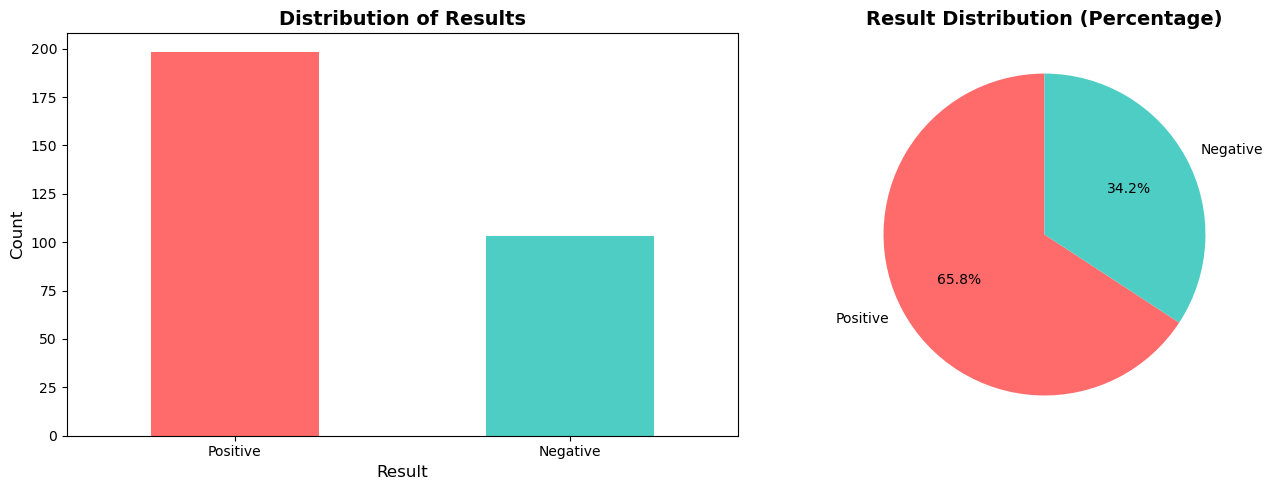

In [10]:
# Count and visualize the target variable
label_counts = df[target_column].value_counts()
print("Label Distribution:")
print(label_counts)
print("\nLabel Proportions:")
print(df[target_column].value_counts(normalize=True))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
label_counts.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Distribution of Results', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Result', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%', 
            colors=['#FF6B6B', '#4ECDC4'], startangle=90)
axes[1].set_title('Result Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Problem Type Classification

In [11]:
# Determine the problem type
unique_labels = df[target_column].nunique()
label_type = df[target_column].dtype

print("Problem Type Analysis:")
print("="*50)
print(f"Target Variable: {target_column}")
print(f"Number of Unique Classes: {unique_labels}")
print(f"Classes: {df[target_column].unique()}")

if label_type == 'object' or label_type == 'category':
    if unique_labels == 2:
        problem_type = "Binary Classification"
    elif unique_labels > 2:
        problem_type = "Multiclass Classification"
else:
    problem_type = "Regression"

print(f"\n✓ This is a {problem_type} problem")
print("\nExplanation:")
if problem_type == "Binary Classification":
    print("- The target variable has exactly 2 classes")
    print("- Suitable for binary classification algorithms")

Problem Type Analysis:
Target Variable: Result
Number of Unique Classes: 2
Classes: ['Positive' 'Negative']

✓ This is a Binary Classification problem

Explanation:
- The target variable has exactly 2 classes
- Suitable for binary classification algorithms


### Train/Validation/Test Splitting (60-20-20)

In [12]:
from sklearn.model_selection import train_test_split

# First split: 60% train, 40% temp (for validation and test)
X = df[feature_columns]
y = df[target_column]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# Second split: Split temp into 50-50 to get 20% validation and 20% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Data Split Summary:")
print("="*50)
print(f"Training set: {len(X_train)} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"Validation set: {len(X_val)} samples ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(df)*100:.1f}%)")
print(f"Total: {len(df)} samples")

print("\nClass distribution in each set:")
print("Training:", y_train.value_counts().to_dict())
print("Validation:", y_val.value_counts().to_dict())
print("Test:", y_test.value_counts().to_dict())

Data Split Summary:
Training set: 180 samples (59.8%)
Validation set: 60 samples (19.9%)
Test set: 61 samples (20.3%)
Total: 301 samples

Class distribution in each set:
Training: {'Positive': 118, 'Negative': 62}
Validation: {'Positive': 40, 'Negative': 20}
Test: {'Positive': 40, 'Negative': 21}


## 2. Data Preprocessing

### Handling Missing Values

In [13]:
from sklearn.impute import SimpleImputer

# Check missing values
print("Missing Values Before Imputation:")
print(df.isnull().sum())
print("\nPercentage of Missing Values:")
print((df.isnull().sum() / len(df) * 100).round(2))

# Create a copy for preprocessing
df_processed = df.copy()

# Handle missing values in numerical columns
numerical_features = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target_column in numerical_features:
    numerical_features.remove(target_column)

# Impute with median for numerical columns
imputer = SimpleImputer(strategy='median')
df_processed[numerical_features] = imputer.fit_transform(df_processed[numerical_features])

print("\n" + "="*50)
print("Missing Values After Imputation:")
print(df_processed.isnull().sum())

Missing Values Before Imputation:
Gender          0
Age             0
Haemoglobin     0
ESR            46
WBC             0
Neutrophil      0
Lymphocyte      1
Monocyte        1
Eosinophil      1
Basophil        1
RBC             1
Platelets       0
Result          0
dtype: int64

Percentage of Missing Values:
Gender          0.00
Age             0.00
Haemoglobin     0.00
ESR            15.28
WBC             0.00
Neutrophil      0.00
Lymphocyte      0.33
Monocyte        0.33
Eosinophil      0.33
Basophil        0.33
RBC             0.33
Platelets       0.00
Result          0.00
dtype: float64

Missing Values After Imputation:
Gender         0
Age            0
Haemoglobin    0
ESR            0
WBC            0
Neutrophil     0
Lymphocyte     0
Monocyte       0
Eosinophil     0
Basophil       0
RBC            0
Platelets      0
Result         0
dtype: int64


### Label Encoding

In [14]:
from sklearn.preprocessing import LabelEncoder

# Apply Label Encoding to categorical columns
df_label_encoded = df_processed.copy()
label_encoders = {}

categorical_features = df_label_encoded.select_dtypes(include=['object']).columns.tolist()

print("Applying Label Encoding...")
print("="*50)
for col in categorical_features:
    le = LabelEncoder()
    df_label_encoded[col] = le.fit_transform(df_label_encoded[col])
    label_encoders[col] = le
    print(f"\n{col}:")
    print(f"  Original values: {le.classes_}")
    print(f"  Encoded values: {list(range(len(le.classes_)))}")

print("\n" + "="*50)
print("Data after Label Encoding:")
print(df_label_encoded.head())

Applying Label Encoding...

Gender:
  Original values: ['Female' 'Male']
  Encoded values: [0, 1]

Result:
  Original values: ['Negative' 'Positive']
  Encoded values: [0, 1]

Data after Label Encoding:
   Gender   Age  Haemoglobin   ESR    WBC  Neutrophil  Lymphocyte  Monocyte  \
0       0  40.0         11.2  32.0  11.30        65.0        23.0      10.0   
1       1  13.0         11.6  59.0   7.80        49.0        42.0       9.0   
2       1  23.0         15.1  16.0   3.85        65.0        25.0       9.0   
3       1  58.0          8.5  16.0  10.30        85.0         6.0       6.0   
4       0  35.0         12.0  28.0   6.70        54.0        20.0       4.0   

   Eosinophil  Basophil   RBC  Platelets  Result  
0         2.0       0.0  4.04       30.0       1  
1         0.0       0.0  4.34       40.0       1  
2         1.0       0.0  5.43       30.0       1  
3         3.0       0.0  3.00       30.0       1  
4         1.0       0.0  4.30       40.0       1  


### Min-Max Normalization

In [16]:
from sklearn.preprocessing import MinMaxScaler

# Apply Min-Max Normalization
df_minmax = df_label_encoded.copy()

# Get numerical columns (excluding target if it's numerical)
numerical_cols_for_scaling = df_minmax.select_dtypes(include=['int64', 'float64']).columns.tolist()

scaler_minmax = MinMaxScaler()
df_minmax[numerical_cols_for_scaling] = scaler_minmax.fit_transform(df_minmax[numerical_cols_for_scaling])

print("Min-Max Normalization Applied:")
print("="*50)
print("Normalized columns:", numerical_cols_for_scaling)
print("\nFirst few rows after normalization:")
print(df_minmax.head())
print("\nStatistics after Min-Max Normalization:")
print(df_minmax[numerical_cols_for_scaling].describe())

Min-Max Normalization Applied:
Normalized columns: ['Gender', 'Age', 'Haemoglobin', 'ESR', 'WBC', 'Neutrophil', 'Lymphocyte', 'Monocyte', 'Eosinophil', 'Basophil', 'RBC', 'Platelets', 'Result']

First few rows after normalization:
   Gender       Age  Haemoglobin       ESR       WBC  Neutrophil  Lymphocyte  \
0     0.0  0.486216     0.542857  0.240310  0.335621    0.693182    0.226190   
1     1.0  0.147870     0.565714  0.449612  0.226450    0.511364    0.452381   
2     1.0  0.273183     0.765714  0.116279  0.103244    0.693182    0.250000   
3     1.0  0.711779     0.388571  0.116279  0.304429    0.920455    0.023810   
4     0.0  0.423559     0.588571  0.209302  0.192140    0.568182    0.190476   

   Monocyte  Eosinophil  Basophil       RBC  Platelets  Result  
0  0.321429    0.222222       0.0  0.571429   0.046729     1.0  
1  0.285714    0.000000       0.0  0.613861   0.065421     1.0  
2  0.285714    0.111111       0.0  0.768034   0.046729     1.0  
3  0.178571    0.333333     

### Z-Score Standardization

In [17]:
from sklearn.preprocessing import StandardScaler

# Apply Z-Score Standardization
df_zscore = df_label_encoded.copy()

scaler_standard = StandardScaler()
df_zscore[numerical_cols_for_scaling] = scaler_standard.fit_transform(df_zscore[numerical_cols_for_scaling])

print("Z-Score Standardization Applied:")
print("="*50)
print("Standardized columns:", numerical_cols_for_scaling)
print("\nFirst few rows after standardization:")
print(df_zscore.head())
print("\nStatistics after Z-Score Standardization:")
print(df_zscore[numerical_cols_for_scaling].describe())

Z-Score Standardization Applied:
Standardized columns: ['Gender', 'Age', 'Haemoglobin', 'ESR', 'WBC', 'Neutrophil', 'Lymphocyte', 'Monocyte', 'Eosinophil', 'Basophil', 'RBC', 'Platelets', 'Result']

First few rows after standardization:
     Gender       Age  Haemoglobin       ESR       WBC  Neutrophil  \
0 -1.289851  0.345867    -0.533550  0.237296  0.734484    0.327507   
1  0.775283 -1.285539    -0.379091  1.291701  0.028372   -0.662621   
2  0.775283 -0.681314     0.972424 -0.387536 -0.768526    0.327507   
3  0.775283  1.433472    -1.576147 -0.387536  0.532738    1.565167   
4 -1.289851  0.043755    -0.224632  0.081088 -0.193549   -0.353206   

   Lymphocyte  Monocyte  Eosinophil  Basophil       RBC  Platelets   Result  
0   -0.596510  1.007881    0.043612 -0.057735 -0.619156  -0.766844  0.72125  
1    0.686469  0.702985   -1.269122 -0.057735 -0.310841  -0.668827  0.72125  
2   -0.461460  0.702985   -0.612755 -0.057735  0.809369  -0.766844  0.72125  
3   -1.744440 -0.211706    0.6

### Similarity and Distance Measures

In [18]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from scipy.spatial.distance import jaccard

# Use normalized data for similarity/distance calculations
numerical_data = df_minmax[numerical_cols_for_scaling].head(10)

# 1. Pearson's Correlation
print("1. Pearson's Correlation (between features):")
print("="*50)
correlation_matrix = df_label_encoded[numerical_cols_for_scaling].corr(method='pearson')
print(correlation_matrix)

# 2. Cosine Similarity
print("\n\n2. Cosine Similarity (between first 5 samples):")
print("="*50)
cosine_sim = cosine_similarity(numerical_data[:5])
print(pd.DataFrame(cosine_sim, 
                   columns=[f'Sample_{i}' for i in range(5)],
                   index=[f'Sample_{i}' for i in range(5)]))

# 3. Euclidean Distance
print("\n\n3. Euclidean Distance (between first 5 samples):")
print("="*50)
euclidean_dist = euclidean_distances(numerical_data[:5])
print(pd.DataFrame(euclidean_dist,
                   columns=[f'Sample_{i}' for i in range(5)],
                   index=[f'Sample_{i}' for i in range(5)]))

# 4. Jaccard Similarity (for binary features)
print("\n\n4. Jaccard Similarity:")
print("="*50)
# Convert some features to binary for demonstration
binary_data = (df_minmax[numerical_cols_for_scaling].head(5) > 0.5).astype(int)
print("Jaccard similarity between first two samples:")
jaccard_sim = 1 - jaccard(binary_data.iloc[0], binary_data.iloc[1])
print(f"Jaccard Similarity: {jaccard_sim:.4f}")

1. Pearson's Correlation (between features):
               Gender       Age  Haemoglobin       ESR       WBC  Neutrophil  \
Gender       1.000000  0.007106     0.410738 -0.280159 -0.221274   -0.074316   
Age          0.007106  1.000000    -0.160277  0.300673  0.053476    0.138094   
Haemoglobin  0.410738 -0.160277     1.000000 -0.497385 -0.242503   -0.161715   
ESR         -0.280159  0.300673    -0.497385  1.000000  0.215756    0.133288   
WBC         -0.221274  0.053476    -0.242503  0.215756  1.000000    0.439764   
Neutrophil  -0.074316  0.138094    -0.161715  0.133288  0.439764    1.000000   
Lymphocyte   0.023270 -0.161564     0.106983 -0.083278 -0.424372   -0.955992   
Monocyte     0.220612 -0.056240     0.335376 -0.238257 -0.248575   -0.376600   
Eosinophil   0.087777  0.009805     0.021249 -0.023549 -0.145579   -0.327217   
Basophil     0.044761 -0.018405     0.024931  0.013700  0.013402    0.018909   
RBC          0.375242 -0.202933     0.826033 -0.496818 -0.238739   -0.21948

## 3. Exploratory Data Analysis (EDA)

### Histogram Plotting

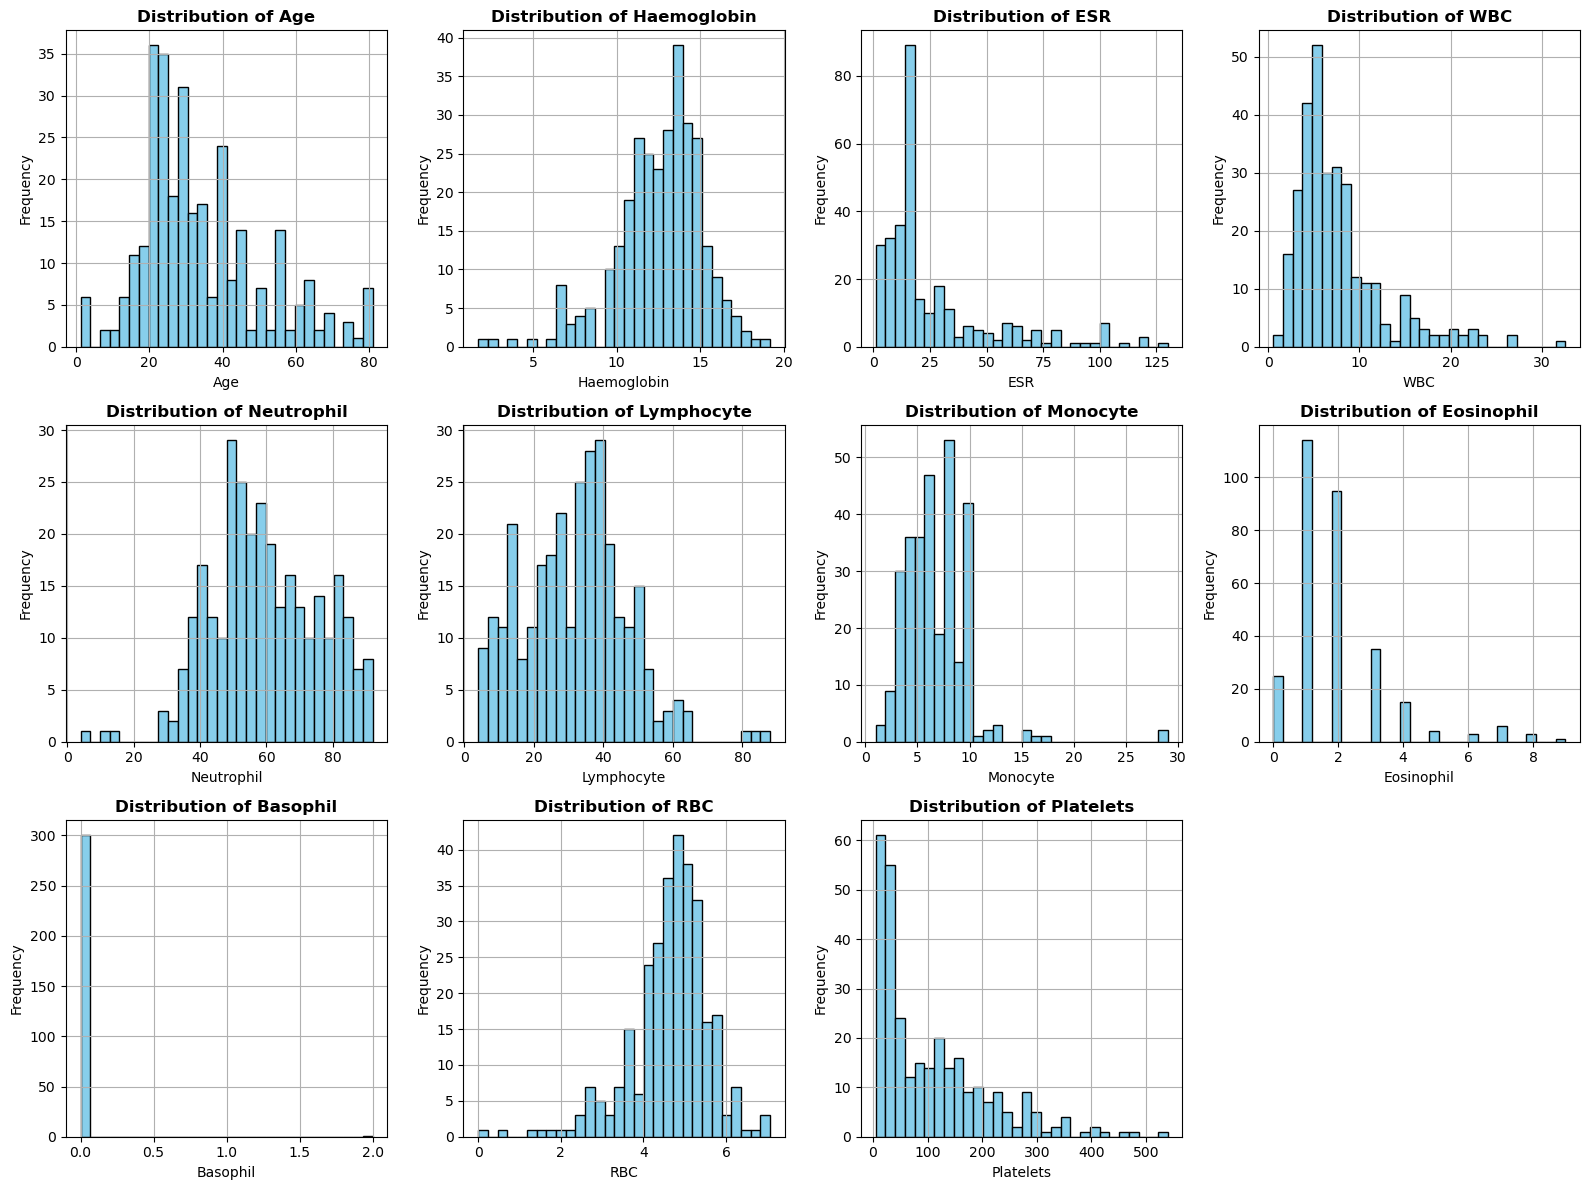

In [19]:
# Plot histograms for all numerical features
numerical_features_viz = [col for col in numerical_features if col in df_processed.columns]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_features_viz):
    df_processed[col].hist(bins=30, ax=axes[idx], color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

# Hide unused subplots
for idx in range(len(numerical_features_viz), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### Boxplot (Outlier Detection)

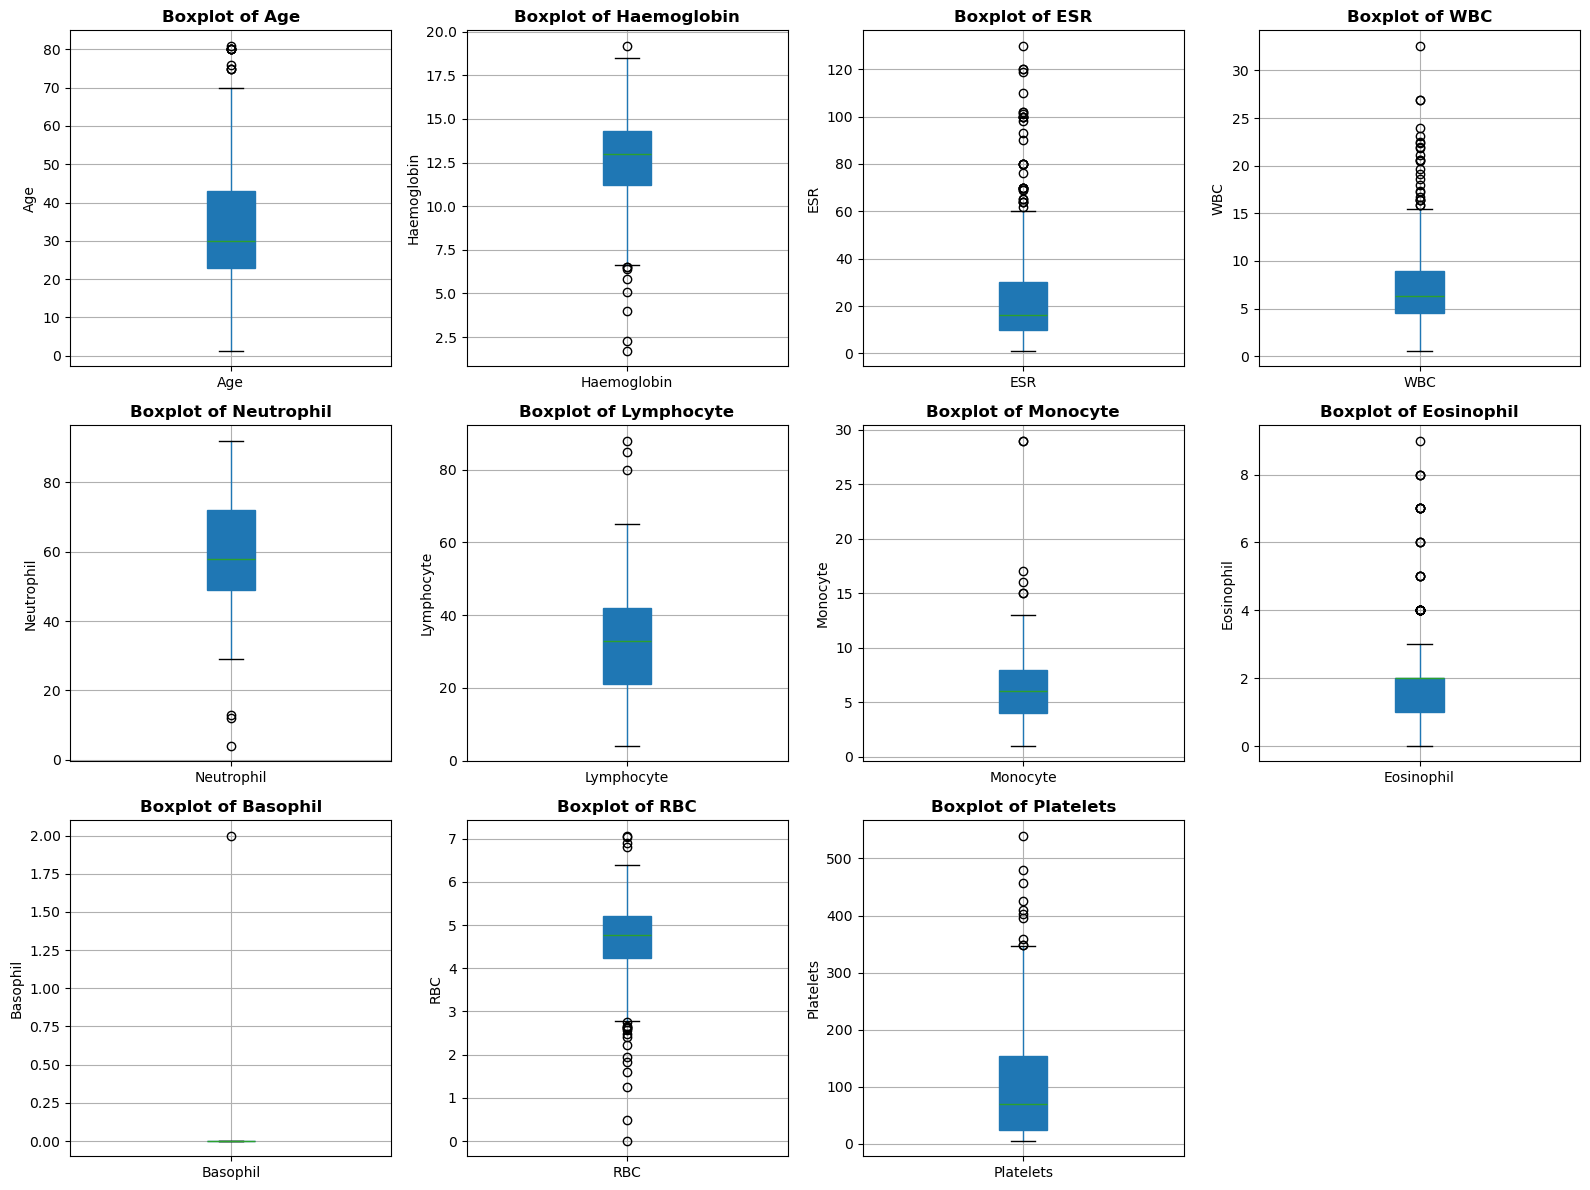

Outlier Detection Summary:
Age: 11 outliers detected
Haemoglobin: 9 outliers detected
ESR: 34 outliers detected
WBC: 25 outliers detected
Neutrophil: 3 outliers detected
Lymphocyte: 3 outliers detected
Monocyte: 6 outliers detected
Eosinophil: 32 outliers detected
Basophil: 1 outliers detected
RBC: 19 outliers detected
Platelets: 10 outliers detected


In [20]:
# Boxplots for outlier detection
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(numerical_features_viz):
    df_processed.boxplot(column=col, ax=axes[idx], patch_artist=True)
    axes[idx].set_title(f'Boxplot of {col}', fontweight='bold')
    axes[idx].set_ylabel(col)

# Hide unused subplots
for idx in range(len(numerical_features_viz), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Detect outliers using IQR method
print("Outlier Detection Summary:")
print("="*50)
for col in numerical_features_viz:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_processed[(df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)][col]
    print(f"{col}: {len(outliers)} outliers detected")

### Correlation Heatmap

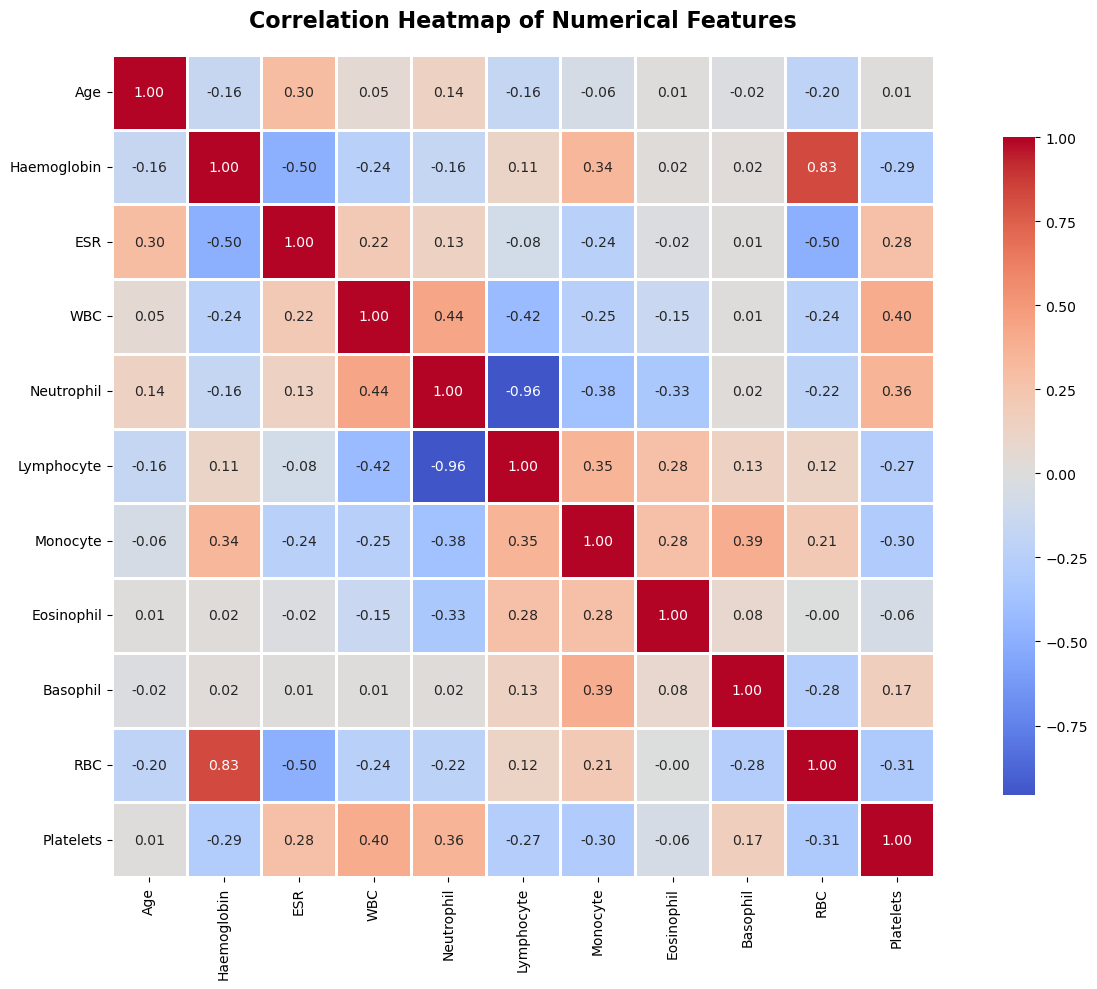


Highly Correlated Feature Pairs (|correlation| > 0.7):
Haemoglobin <-> RBC: 0.826
Neutrophil <-> Lymphocyte: -0.956


In [21]:
import seaborn as sns

# Create correlation matrix
correlation_matrix = df_label_encoded[numerical_features].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Find highly correlated features
print("\nHighly Correlated Feature Pairs (|correlation| > 0.7):")
print("="*50)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            print(f"{correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")

## 4. Mining Frequent Itemsets and Association Rules

For association rule mining, we'll discretize numerical features into categorical bins to find interesting patterns.

In [23]:
%pip install mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.4 MB ? eta -:--:--Downloading mlxtend-0.23.4-py3-none-any.whl (1.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 3.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 3.6 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [24]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Prepare data for association rule mining by discretizing continuous variables
df_discretized = df_processed.copy()

# Discretize numerical features into Low, Medium, High
for col in numerical_features_viz[:5]:  # Use first 5 numerical features
    df_discretized[f'{col}_category'] = pd.cut(df_processed[col], 
                                                bins=3, 
                                                labels=[f'{col}_Low', f'{col}_Medium', f'{col}_High'])

# Create a binary encoded dataset for apriori
categorical_cols = [col for col in df_discretized.columns if '_category' in col]
df_binary = pd.get_dummies(df_discretized[categorical_cols + [target_column]])

# Apply Apriori Algorithm
frequent_itemsets = apriori(df_binary, min_support=0.3, use_colnames=True)
print("Frequent Itemsets:")
print("="*50)
print(frequent_itemsets.head(10))

# Generate Association Rules
if len(frequent_itemsets) > 0:
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
    rules['lift'] = rules['lift']
    
    print("\n\nAssociation Rules:")
    print("="*50)
    print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))
    
    print("\n\nTop 5 Rules by Lift:")
    print("="*50)
    print(rules.nlargest(5, 'lift')[['antecedents', 'consequents', 'support', 'confidence', 'lift']])
else:
    print("No frequent itemsets found with the given support threshold")

Frequent Itemsets:
    support                                   itemsets
0  0.425249                     (Age_category_Age_Low)
1  0.421927                  (Age_category_Age_Medium)
2  0.511628  (Haemoglobin_category_Haemoglobin_Medium)
3  0.435216    (Haemoglobin_category_Haemoglobin_High)
4  0.833887                     (ESR_category_ESR_Low)
5  0.833887                     (WBC_category_WBC_Low)
6  0.578073    (Neutrophil_category_Neutrophil_Medium)
7  0.395349      (Neutrophil_category_Neutrophil_High)
8  0.342193                          (Result_Negative)
9  0.657807                          (Result_Positive)


Association Rules:
                                 antecedents  \
0                     (Age_category_Age_Low)   
1                     (Age_category_Age_Low)   
2                  (Age_category_Age_Medium)   
3                  (Age_category_Age_Medium)   
4  (Haemoglobin_category_Haemoglobin_Medium)   
5  (Haemoglobin_category_Haemoglobin_Medium)   
6    (Haemoglobin_c

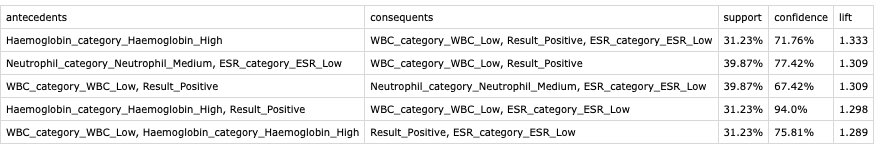

## 5. Classification Methods

In [25]:
# Prepare data for classification
from sklearn.preprocessing import LabelEncoder

# Use label encoded data
X_class = df_label_encoded.drop(columns=[target_column])
y_class = df_label_encoded[target_column]

# Split data
X_train_c, X_temp_c, y_train_c, y_temp_c = train_test_split(X_class, y_class, test_size=0.4, random_state=42)
X_val_c, X_test_c, y_val_c, y_test_c = train_test_split(X_temp_c, y_temp_c, test_size=0.5, random_state=42)

print("Classification Dataset Prepared:")
print(f"Training: {X_train_c.shape}")
print(f"Validation: {X_val_c.shape}")
print(f"Test: {X_test_c.shape}")

Classification Dataset Prepared:
Training: (180, 12)
Validation: (60, 12)
Test: (61, 12)


### Decision Tree Classification

In [26]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import numpy as np

# Train Decision Tree with Entropy (ID3-like)
dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
dt_entropy.fit(X_train_c, y_train_c)

# Train Decision Tree with Gini Index (CART)
dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_gini.fit(X_train_c, y_train_c)

# Predictions
y_pred_entropy = dt_entropy.predict(X_test_c)
y_pred_gini = dt_gini.predict(X_test_c)

# Evaluation
print("Decision Tree with Entropy (Information Gain):")
print("="*50)
print(f"Training Accuracy: {accuracy_score(y_train_c, dt_entropy.predict(X_train_c)):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val_c, dt_entropy.predict(X_val_c)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test_c, y_pred_entropy):.4f}")

print("\n\nDecision Tree with Gini Index:")
print("="*50)
print(f"Training Accuracy: {accuracy_score(y_train_c, dt_gini.predict(X_train_c)):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val_c, dt_gini.predict(X_val_c)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test_c, y_pred_gini):.4f}")

# Cross-validation
cv_scores = cross_val_score(dt_entropy, X_class, y_class, cv=5)
print(f"\n\n5-Fold Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Decision Tree with Entropy (Information Gain):
Training Accuracy: 0.9444
Validation Accuracy: 0.8667
Test Accuracy: 0.9344


Decision Tree with Gini Index:
Training Accuracy: 0.9722
Validation Accuracy: 0.8500
Test Accuracy: 0.9180


5-Fold Cross-Validation Scores: [0.91803279 0.9        0.78333333 0.81666667 0.78333333]
Mean CV Accuracy: 0.8403 (+/- 0.1154)


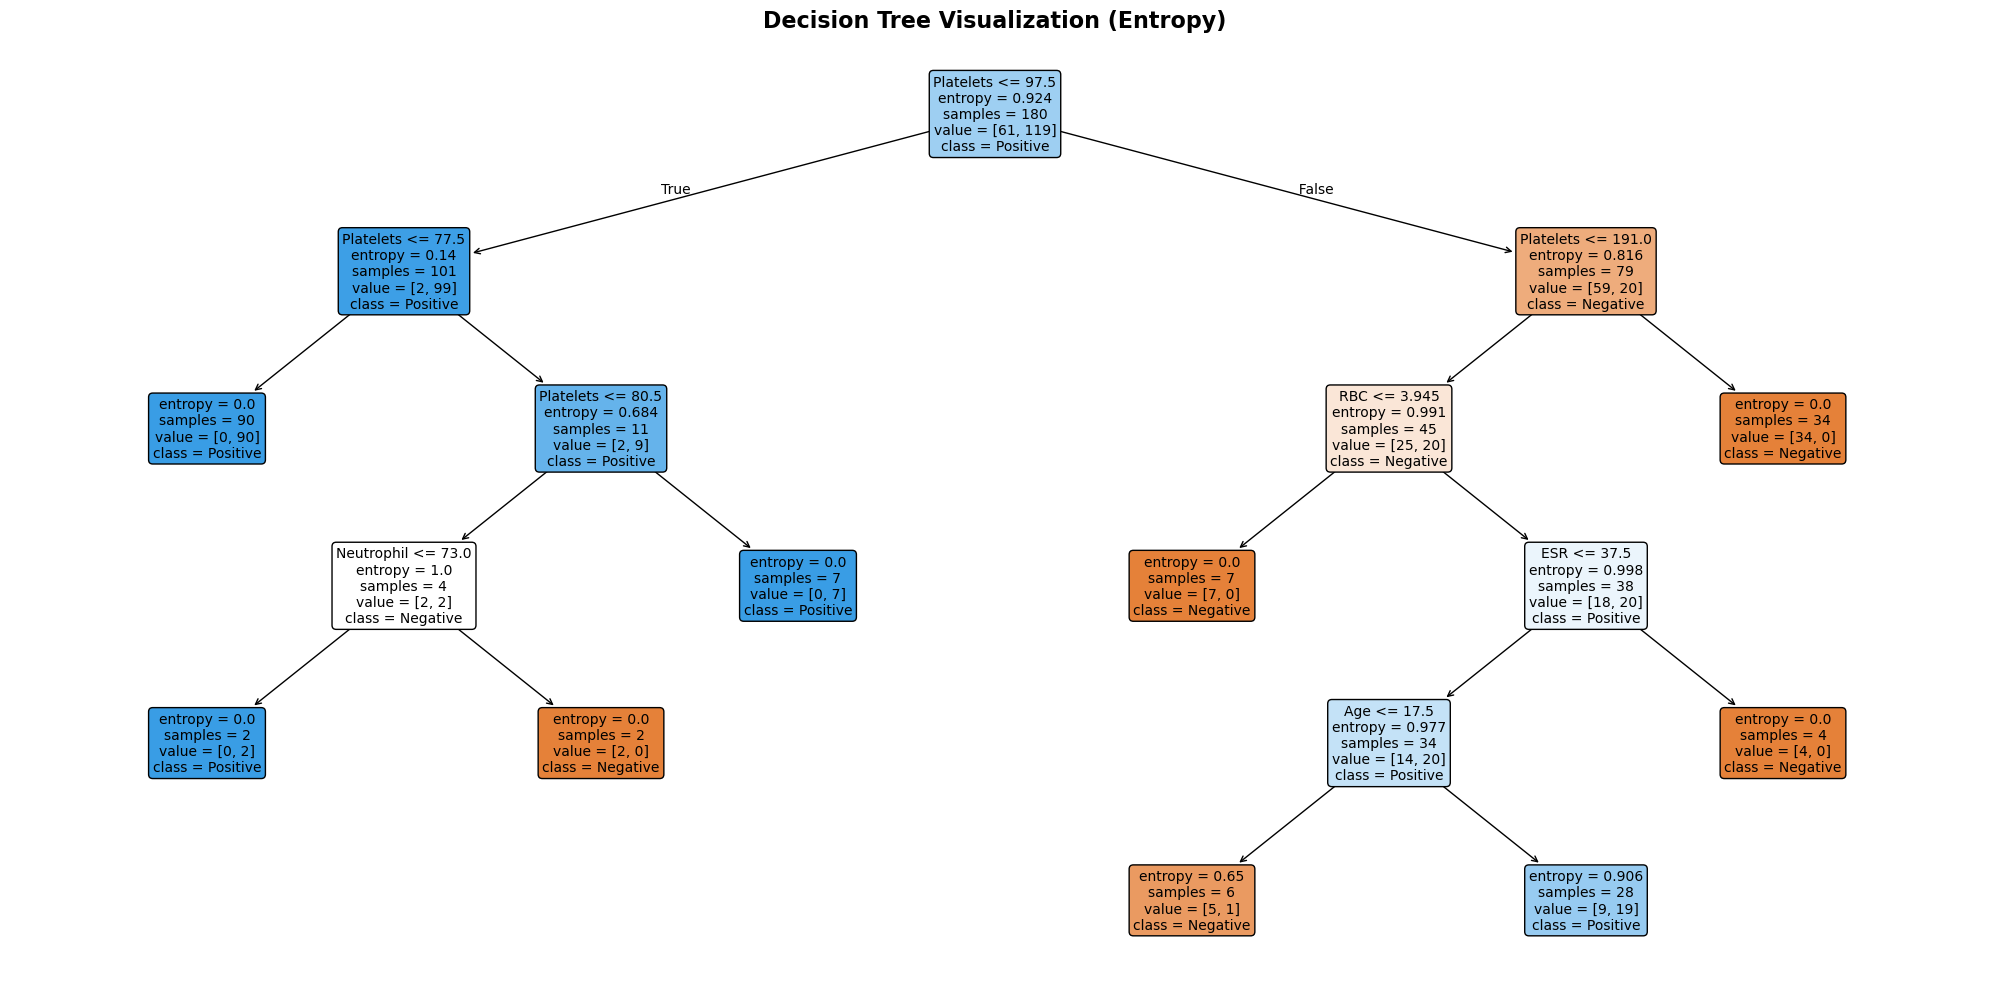


Feature Importance:
        Feature  Importance
11    Platelets    0.858898
10          RBC    0.048715
3           ESR    0.034245
5    Neutrophil    0.029195
1           Age    0.028948
0        Gender    0.000000
2   Haemoglobin    0.000000
4           WBC    0.000000
6    Lymphocyte    0.000000
7      Monocyte    0.000000
8    Eosinophil    0.000000
9      Basophil    0.000000


In [27]:
# Visualize Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dt_entropy, 
          feature_names=X_train_c.columns, 
          class_names=['Negative', 'Positive'],
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Visualization (Entropy)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train_c.columns,
    'Importance': dt_entropy.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print("="*50)
print(feature_importance)

### Naïve Bayes Classification

Naïve Bayes Classification Results:
Training Accuracy: 0.8111
Validation Accuracy: 0.7333
Test Accuracy: 0.8525


Confusion Matrix:
[[11  7]
 [ 2 41]]


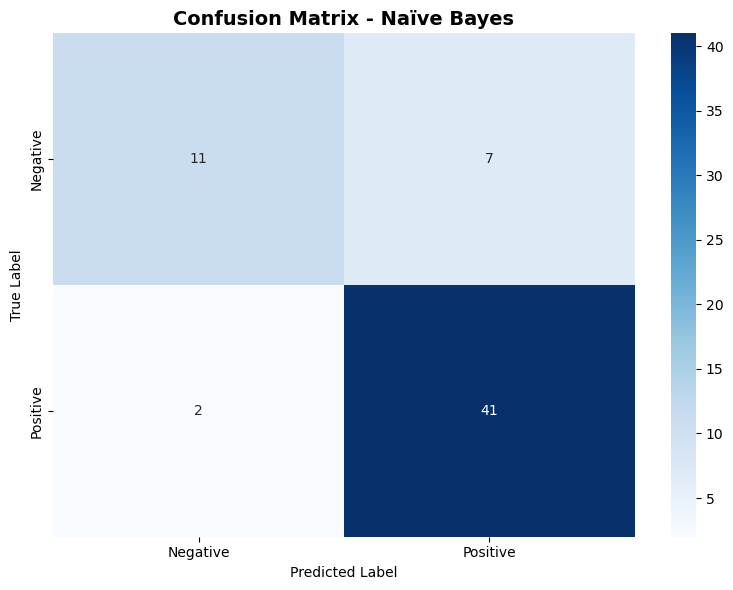



Precision, Recall, and F1-Score:
Precision: 0.8518
Recall: 0.8525
F1-Score: 0.8446


Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.61      0.71        18
    Positive       0.85      0.95      0.90        43

    accuracy                           0.85        61
   macro avg       0.85      0.78      0.81        61
weighted avg       0.85      0.85      0.84        61



In [28]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score, recall_score, f1_score

# Train Gaussian Naïve Bayes (with Laplace Smoothing built-in)
nb_model = GaussianNB()
nb_model.fit(X_train_c, y_train_c)

# Predictions
y_pred_nb = nb_model.predict(X_test_c)
y_pred_nb_proba = nb_model.predict_proba(X_test_c)

# Evaluation
print("Naïve Bayes Classification Results:")
print("="*50)
print(f"Training Accuracy: {accuracy_score(y_train_c, nb_model.predict(X_train_c)):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val_c, nb_model.predict(X_val_c)):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test_c, y_pred_nb):.4f}")

print("\n\nConfusion Matrix:")
print("="*50)
cm = confusion_matrix(y_test_c, y_pred_nb)
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Naïve Bayes', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Precision, Recall, F1-Score
print("\n\nPrecision, Recall, and F1-Score:")
print("="*50)
print(f"Precision: {precision_score(y_test_c, y_pred_nb, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test_c, y_pred_nb, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test_c, y_pred_nb, average='weighted'):.4f}")

print("\n\nDetailed Classification Report:")
print("="*50)
print(classification_report(y_test_c, y_pred_nb, target_names=['Negative', 'Positive']))

## 6. Clustering Methods

### K-Means Clustering with Elbow Method

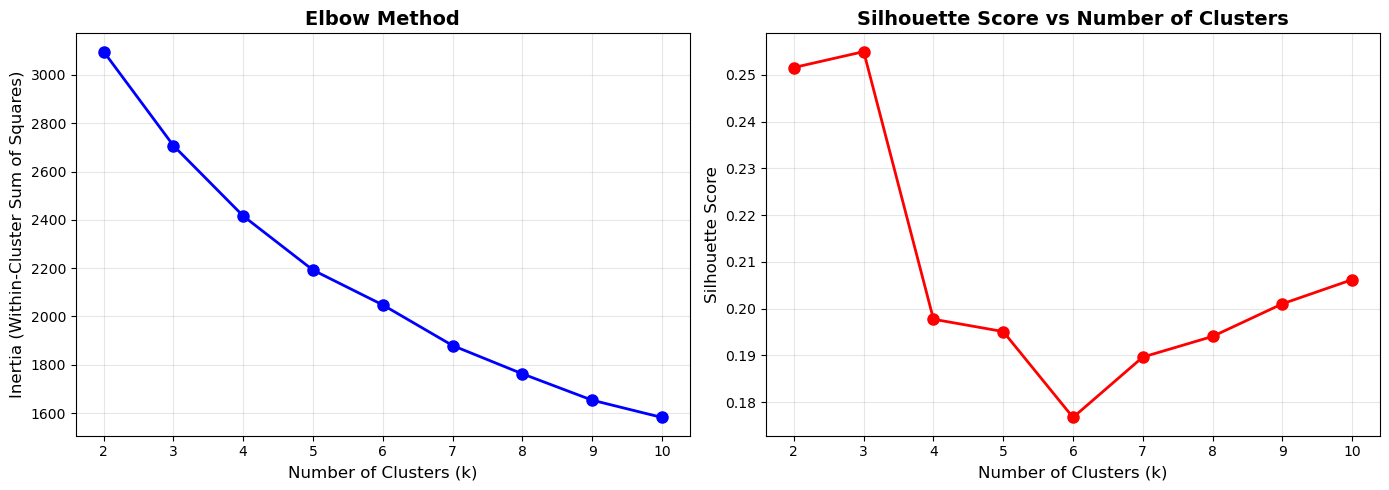

Silhouette Scores for different k values:
k=2: 0.2516
k=3: 0.2550
k=4: 0.1978
k=5: 0.1951
k=6: 0.1768
k=7: 0.1897
k=8: 0.1941
k=9: 0.2010
k=10: 0.2062


In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Prepare data for clustering (use standardized data)
X_clustering = df_zscore[numerical_cols_for_scaling]

# Elbow Method to find optimal k
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clustering)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_clustering, kmeans.labels_))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Silhouette Scores for different k values:")
print("="*50)
for k, score in zip(K_range, silhouette_scores):
    print(f"k={k}: {score:.4f}")

K-Means Clustering with k=3:
Silhouette Score: 0.2550

Cluster Distribution:
Cluster
0    198
1    102
2      1
Name: count, dtype: int64


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


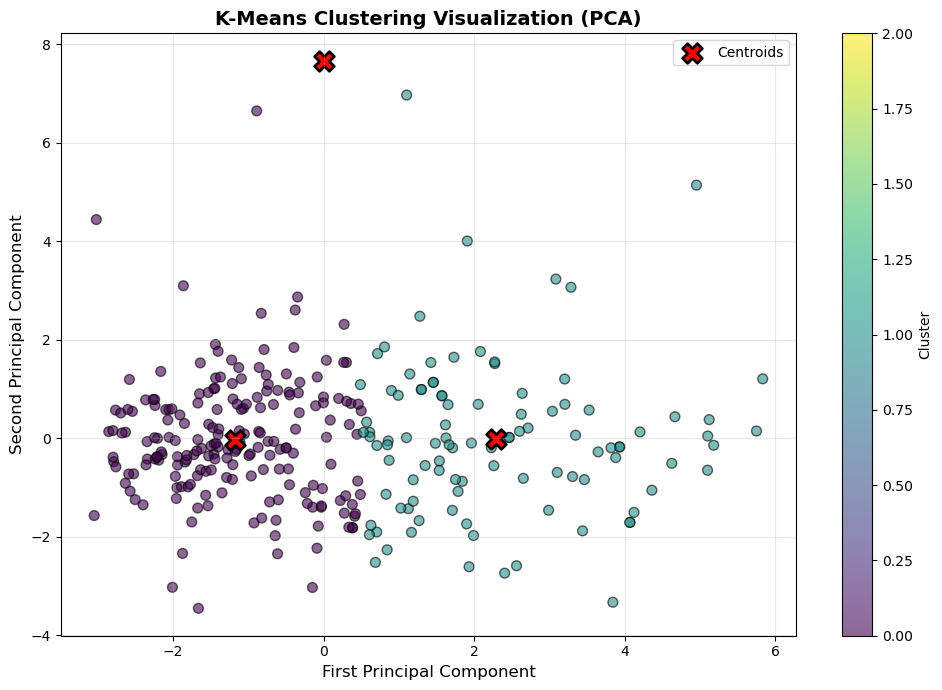

In [31]:
# Apply K-Means with optimal k (let's use k=3 based on analysis)
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_clustering)

# Add cluster labels to the dataframe
df_clustered = df_zscore.copy()
df_clustered['Cluster'] = clusters

print(f"K-Means Clustering with k={optimal_k}:")
print("="*50)
print(f"Silhouette Score: {silhouette_score(X_clustering, clusters):.4f}")
print(f"\nCluster Distribution:")
print(df_clustered['Cluster'].value_counts().sort_index())

# Visualize clusters using PCA for dimensionality reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clustering)

# Transform cluster centers to PCA space
centers_pca = pca.transform(kmeans_final.cluster_centers_)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', 
                     s=50, alpha=0.6, edgecolors='black')
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], marker='X', s=200, c='red', 
           edgecolors='black', linewidths=2, label='Centroids')
plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title('K-Means Clustering Visualization (PCA)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Hierarchical Clustering with Dendrogram

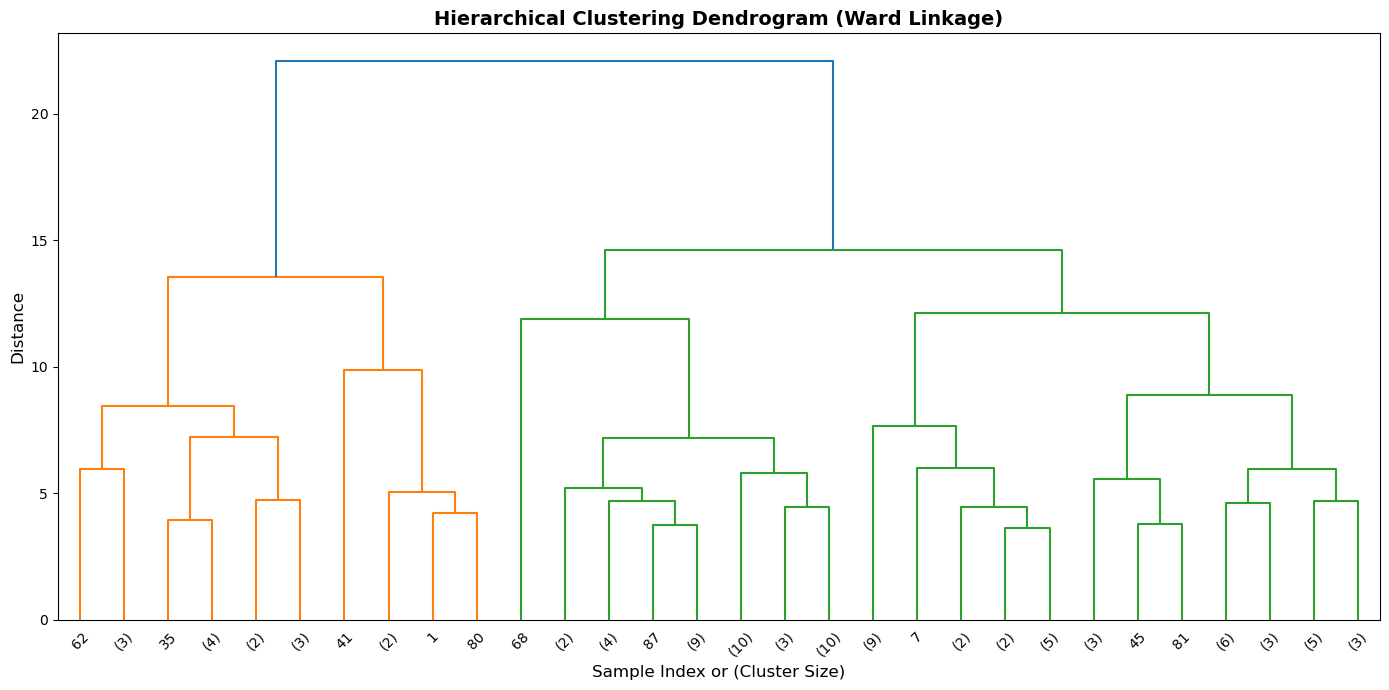

Hierarchical Clustering Results:
Silhouette Score: 0.3077

Cluster Distribution:
0    245
1     55
2      1
Name: count, dtype: int64


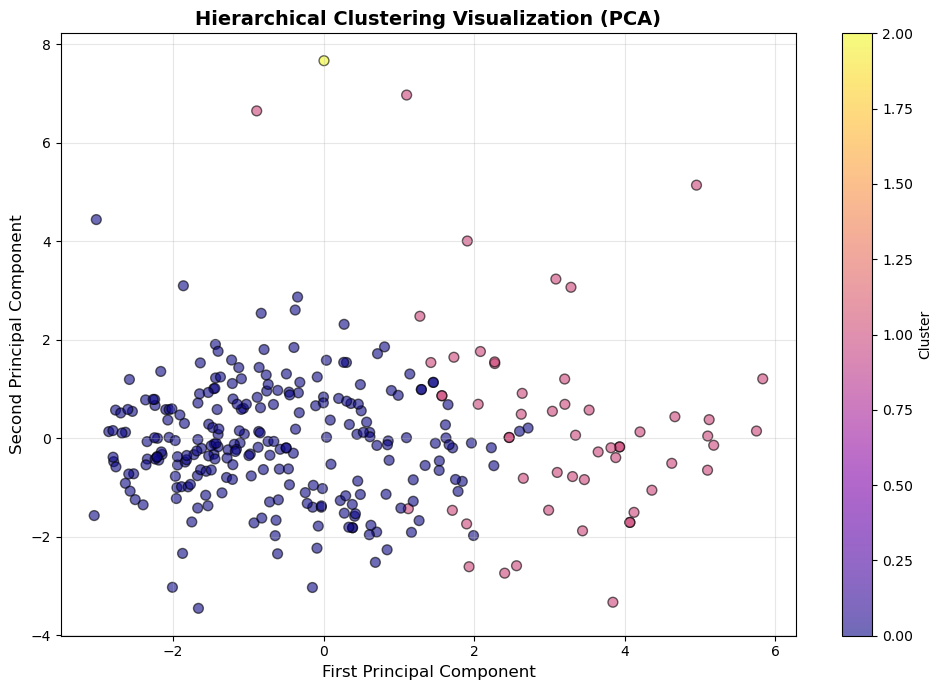

In [32]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Perform hierarchical clustering using different linkage methods
# Use a sample for better visualization
sample_size = 100
X_sample = X_clustering.sample(n=sample_size, random_state=42)

# Create linkage matrix
linkage_matrix = linkage(X_sample, method='ward')

# Plot Dendrogram
plt.figure(figsize=(14, 7))
dendrogram(linkage_matrix, 
           truncate_mode='lastp',
           p=30,
           leaf_font_size=10,
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index or (Cluster Size)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.tight_layout()
plt.show()

# Apply Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_clustering)

# Evaluate
print("Hierarchical Clustering Results:")
print("="*50)
print(f"Silhouette Score: {silhouette_score(X_clustering, agg_labels):.4f}")
print(f"\nCluster Distribution:")
print(pd.Series(agg_labels).value_counts().sort_index())

# Visualize hierarchical clustering results
X_pca_full = pca.transform(X_clustering)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca_full[:, 0], X_pca_full[:, 1], c=agg_labels, 
                     cmap='plasma', s=50, alpha=0.6, edgecolors='black')
plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title('Hierarchical Clustering Visualization (PCA)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()